In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

Saved: E:\LLM+XWT\最终版代码\训练结果\图\esm2_6_learning_curve.png


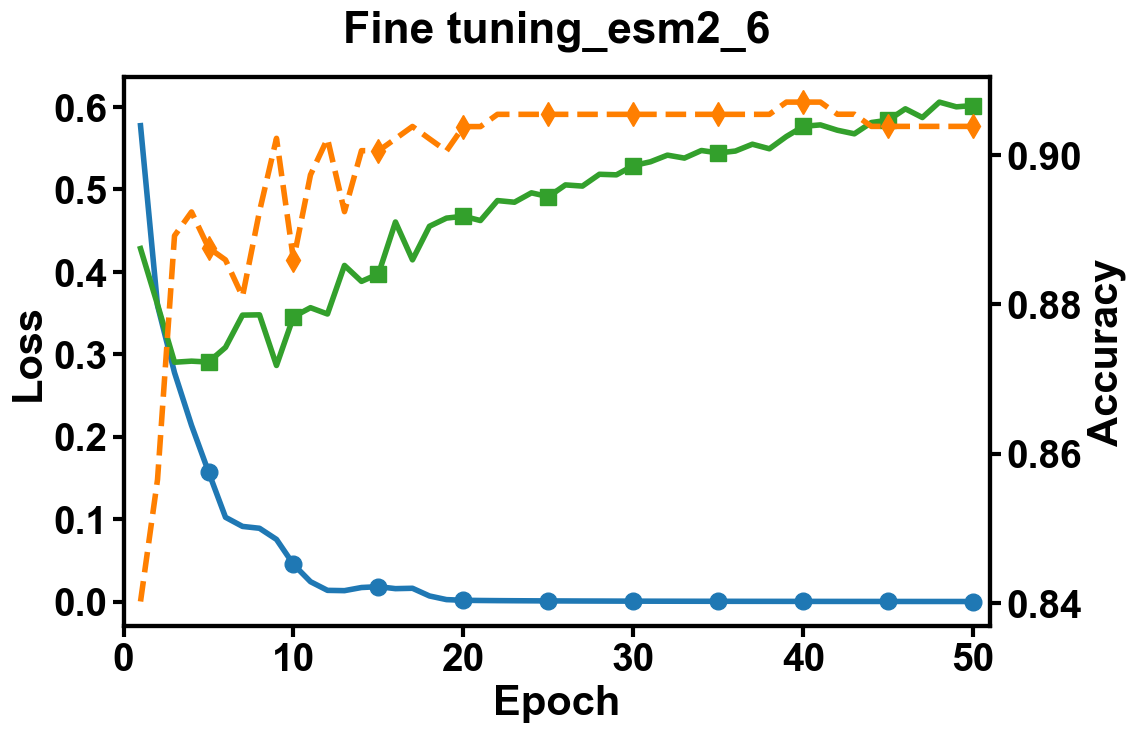

Saved: E:\LLM+XWT\最终版代码\训练结果\图\esm2_12_learning_curve.png


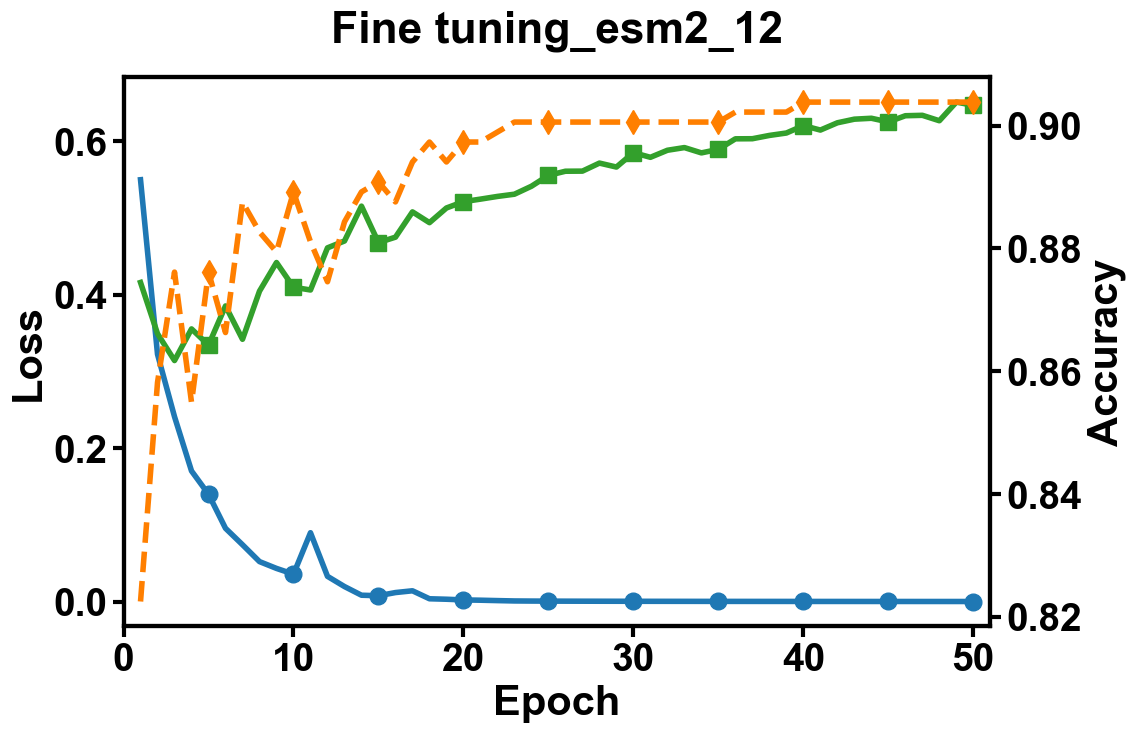

Saved: E:\LLM+XWT\最终版代码\训练结果\图\esm2_30_learning_curve.png


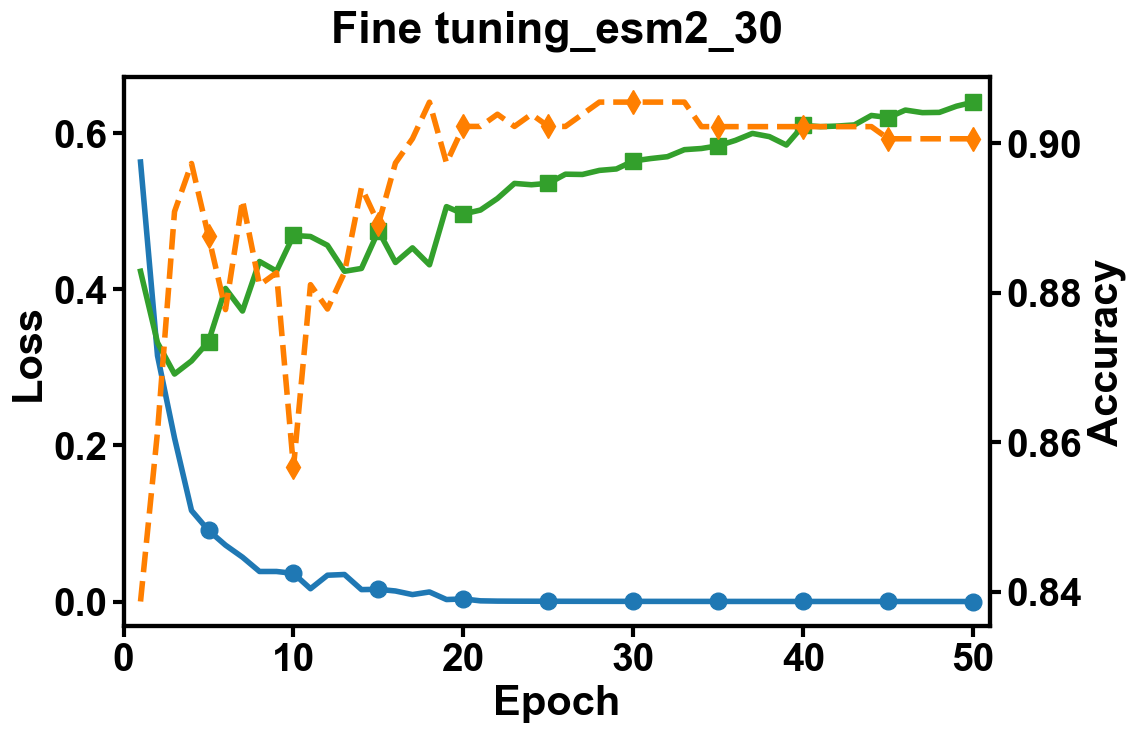

In [23]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. 路径配置 ---
# 数据读取路径
save_dir_6 = 'E:/LLM+XWT/最终版代码/训练结果/训练过程2_6/'
save_dir_12 = 'E:/LLM+XWT/最终版代码/训练结果/训练过程2_12/'
save_dir_30 = 'E:/LLM+XWT/最终版代码/训练结果/训练过程2_30/'

# 图片保存路径 (修改为你指定的位置)
img_save_dir = r'E:\LLM+XWT\最终版代码\训练结果\图'
if not os.path.exists(img_save_dir):
    os.makedirs(img_save_dir)
    print(f"Created directory: {img_save_dir}")

models_info = [
    {'name': 'esm2_6', 'path': save_dir_6},
    {'name': 'esm2_12', 'path': save_dir_12},
    {'name': 'esm2_30', 'path': save_dir_30}
]

# --- 2. 样式设置 ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['font.size'] = 28 

# 颜色
color_train_loss = "#1F78B4" 
color_val_loss = "#33A02C"   
color_val_acc = "#FF7F00"    

def plot_and_save_learning_curve(model_name, save_dir):
    # 读取数据
    file_path = os.path.join(save_dir, f'{model_name}_history.pkl')
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    with open(file_path, 'rb') as f:
        history = pickle.load(f)

    # 计算 5 折平均值
    epochs = len(history['fold_1']['train_loss']) 
    x_axis = range(1, epochs + 1)

    train_losses = []
    val_losses = []
    val_accs = []

    for i in range(1, 6):
        fold_data = history[f'fold_{i}']
        train_losses.append(fold_data['train_loss'])
        val_losses.append(fold_data['val_loss'])
        val_accs.append(fold_data['val_acc'])

    mean_train_loss = np.mean(train_losses, axis=0)
    mean_val_loss = np.mean(val_losses, axis=0)
    mean_val_acc = np.mean(val_accs, axis=0)

    # 绘图
    fig, ax1 = plt.subplots(figsize=(12, 8))

    # X 轴刻度 (以10为梯度)
    ax1.set_xticks(np.arange(0, epochs + 1, 10)) 
    ax1.set_xlim(0, epochs + 1)

    # 标记点频率 (以5为梯度)
    marker_step = slice(4, epochs, 5) 

    # 左轴：Loss
    ax1.set_xlabel('Epoch', fontsize=30, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=30, fontweight='bold')
    
    l1, = ax1.plot(x_axis, mean_train_loss, color=color_train_loss, 
                   marker='o', markersize=12, markevery=marker_step, 
                   label='Train Loss', linewidth=4)
    l2, = ax1.plot(x_axis, mean_val_loss, color=color_val_loss, 
                   marker='s', markersize=12, markevery=marker_step, 
                   label='Validation Loss', linewidth=4)
    
    ax1.tick_params(axis='both', labelsize=28, width=3, length=8)
    for spine in ax1.spines.values():
        spine.set_linewidth(3)

    # 右轴：Accuracy
    ax2 = ax1.twinx()  
    ax2.set_ylabel('Accuracy', fontsize=30, fontweight='bold')
    l3, = ax2.plot(x_axis, mean_val_acc, color=color_val_acc, 
                   marker='d', markersize=12, markevery=marker_step, 
                   linestyle='--', label='Validation Accuracy', linewidth=4)
    
    ax2.tick_params(axis='y', labelsize=28, width=3, length=8)
    for spine in ax2.spines.values():
        spine.set_linewidth(3)

    # 图例
   # lines = [l1, l2, l3]
    #labels = [l.get_label() for l in lines]
    #ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.25), 
          #     ncol=2, frameon=False, fontsize=28, columnspacing=1.0)

    # 标题
    plt.title(f"Fine tuning_{model_name}", fontsize=32, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    
    # --- 保存图片 ---
    save_path = os.path.join(img_save_dir, f'{model_name}_learning_curve.png')
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"Saved: {save_path}")
    
    plt.show()

# 循环执行
for info in models_info:
    plot_and_save_learning_curve(info['name'], info['path'])

Saved standalone legend: E:\LLM+XWT\最终版代码\训练结果\图\training_legend_only.png


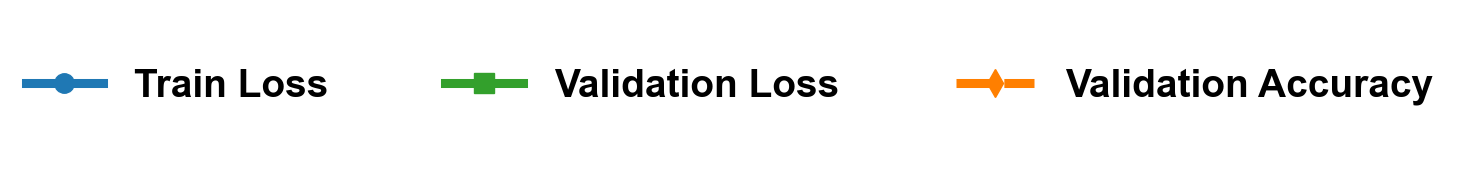

In [34]:

# 图片保存路径
img_save_dir = r'E:\LLM+XWT\最终版代码\训练结果\图'
if not os.path.exists(img_save_dir):
    os.makedirs(img_save_dir)

# --- 样式必须与主图保持一致 ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 28

# 颜色和样式定义
color_train_loss = "#1F78B4" 
color_val_loss = "#33A02C"   
color_val_acc = "#FF7F00"
linewidth = 6.5
markersize = 14

# 创建画布
# figsize=(宽度, 高度)
fig_leg, ax_leg = plt.subplots(figsize=(18, 2)) 

# --- 【关键修改点】 ---
# 将 x, y 数据从 [0], [0] 改为 [], []
# 这样只保留线条对象用于生成图例，但不会在画布上画出任何实际的点
l1, = ax_leg.plot([], [], color=color_train_loss, marker='o', 
                  markersize=markersize, linewidth=linewidth, label='Train Loss')

l2, = ax_leg.plot([], [], color=color_val_loss, marker='s', 
                  markersize=markersize, linewidth=linewidth, label='Validation Loss')

l3, = ax_leg.plot([], [], color=color_val_acc, marker='d', linestyle='--',
                  markersize=markersize, linewidth=linewidth, label='Validation Accuracy')

# 隐藏坐标轴
ax_leg.axis('off')

# 生成图例
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]

# 调整 columnspacing 可以改变图例之间的间距
legend = ax_leg.legend(lines, labels, loc='center', ncol=3, frameon=False, columnspacing=3.0)

# 保存图例
save_path = os.path.join(img_save_dir, 'training_legend_only.png')
fig_leg.savefig(save_path, dpi=600, bbox_inches='tight', pad_inches=0.1)

print(f"Saved standalone legend: {save_path}")
plt.show()

Saved: E:\LLM+XWT\最终版代码\训练结果\图\model_performance_comparison.png


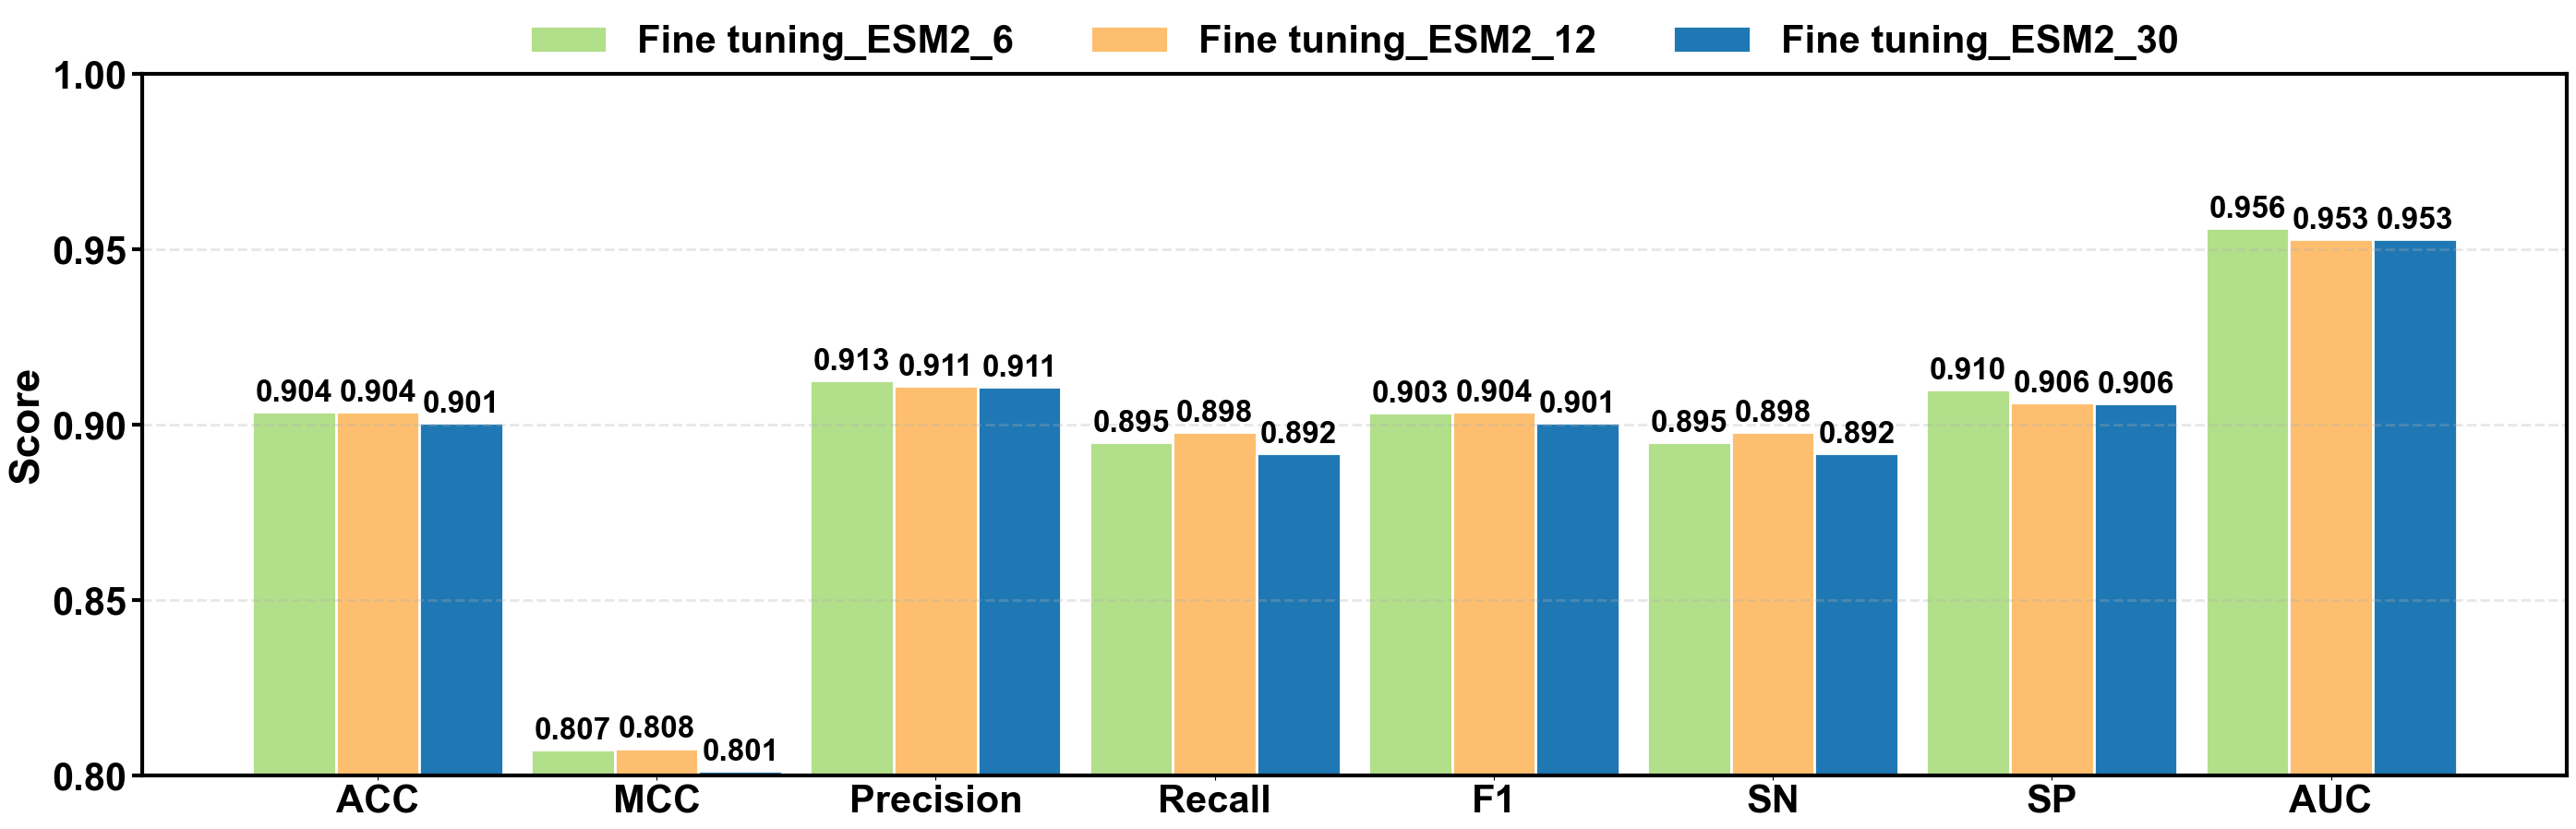

In [10]:
# --- 1. 路径配置 ---
save_dir_6 = 'E:/LLM+XWT/最终版代码/训练结果/训练过程2_6/'
save_dir_12 = 'E:/LLM+XWT/最终版代码/训练结果/训练过程2_12/'
save_dir_30 = 'E:/LLM+XWT/最终版代码/训练结果/训练过程2_30/'

# 图片保存路径
img_save_dir = r'E:\LLM+XWT\最终版代码\训练结果\图'
if not os.path.exists(img_save_dir):
    os.makedirs(img_save_dir)

models_config = [
    {'name': 'esm2_6', 'path': save_dir_6, 'label': 'Fine tuning_ESM2_6'},
    {'name': 'esm2_12', 'path': save_dir_12, 'label': 'Fine tuning_ESM2_12'},
    {'name': 'esm2_30', 'path': save_dir_30, 'label': 'Fine tuning_ESM2_30'}
]

metrics_order = ['val_acc', 'val_mcc', 'val_prec', 'val_sn', 'val_f1', 'val_sn', 'val_sp', 'val_auc']
metrics_labels = ['ACC', 'MCC', 'Precision', 'Recall', 'F1', 'SN', 'SP', 'AUC']

# 准备数据
performance_data = {m['name']: [] for m in models_config}

for config in models_config:
    file_path = os.path.join(config['path'], f"{config['name']}_history.pkl")
    
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found.")
        continue
        
    with open(file_path, 'rb') as f:
        hist = pickle.load(f)
    
    # 提取指标
    for metric_key in metrics_order:
        fold_values = [hist[f'fold_{i}'][metric_key][-1] for i in range(1, 6)]
        avg_value = np.mean(fold_values)
        performance_data[config['name']].append(avg_value)

# --- 2. 绘图 ---
x = np.arange(len(metrics_labels))
width = 0.30

fig, ax = plt.subplots(figsize=(28, 9))

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'

# 颜色
color_model_1 = "#B2DF8A" # esm2_6
color_model_2 = "#FDBF6F" # esm2_12
color_model_3 = "#1F78B4" # esm2_30
colors = [color_model_1, color_model_2, color_model_3]

# 绘制柱状图
for i, config in enumerate(models_config):
    model_name = config['name']
    offset = (i - 1) * width 
    values = performance_data[model_name]
    
    rects = ax.bar(x + offset, values, width, label=config['label'], 
                   color=colors[i], edgecolor='white', linewidth=2)
    
    # 标注数值
    ax.bar_label(rects, padding=3, fmt='%.3f', fontsize=24, fontweight='bold')

# 坐标轴设置
ax.set_ylabel('Score', fontsize=33, fontweight='bold')
ax.set_xticks(x, metrics_labels, fontsize=30, fontweight='bold')
ax.tick_params(axis='y', labelsize=30, width=3, length=8)
ax.set_ylim(0.8, 1.0) 
yticks = np.arange(0.80, 1.001, 0.05)
ax.set_yticks(yticks)


for spine in ax.spines.values():
    spine.set_linewidth(3)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False, fontsize=30)
ax.grid(axis='y', linestyle='--', alpha=0.3, linewidth=2)

plt.tight_layout()

# --- 保存图片 ---
save_path = os.path.join(img_save_dir, 'model_performance_comparison.png')
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"Saved: {save_path}")

plt.show()

Saved: E:\LLM+XWT\最终版代码\训练结果\图\model_performance_comparison_best.png


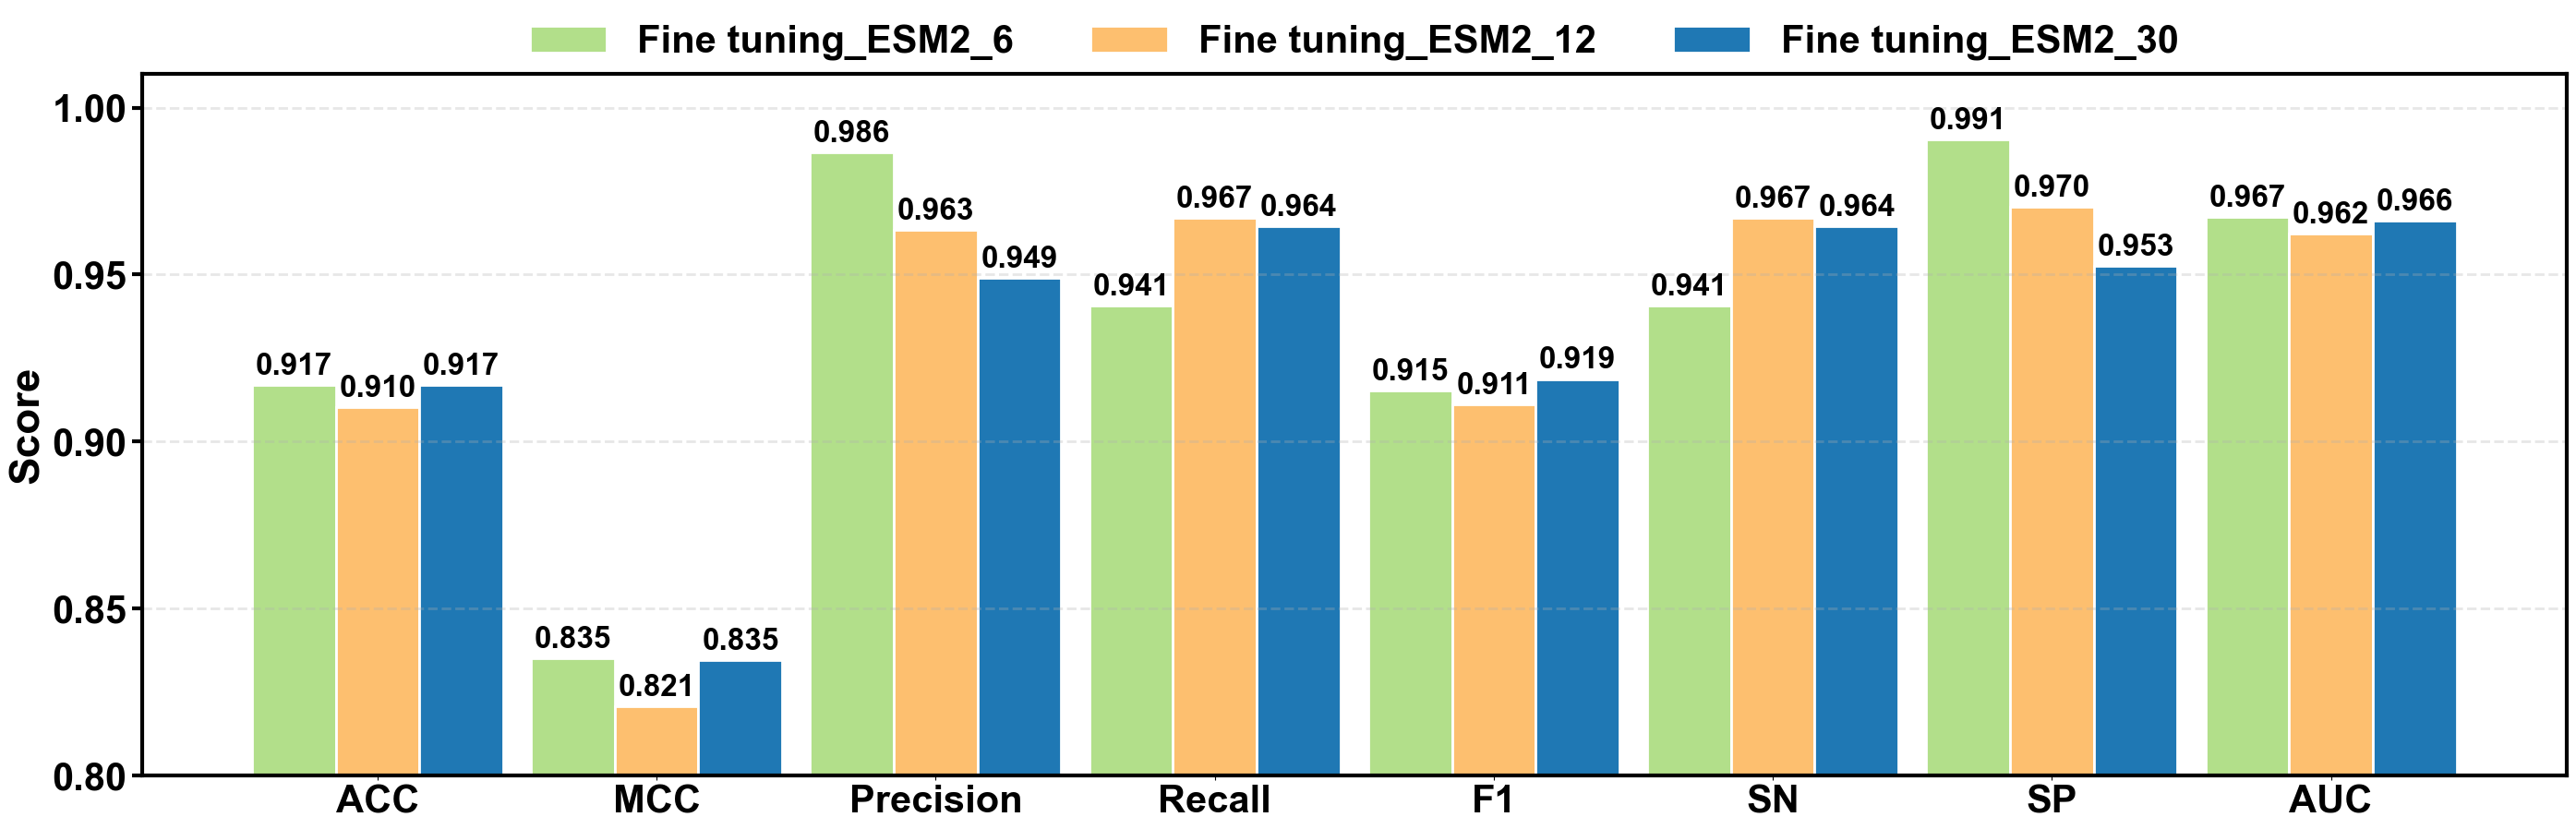

In [3]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. 路径配置 ---
# 使用您提供的最新路径
save_dir_6 = 'E:/LLM+XWT/最终版代码/训练结果/训练过程2_6/'
save_dir_12 = 'E:/LLM+XWT/最终版代码/训练结果/训练过程2_12/'
save_dir_30 = 'E:/LLM+XWT/最终版代码/训练结果/训练过程2_30/'

# 图片保存路径
img_save_dir = r'E:\LLM+XWT\最终版代码\训练结果\图'
if not os.path.exists(img_save_dir):
    os.makedirs(img_save_dir)
    print(f"Created directory: {img_save_dir}")

models_config = [
    {'name': 'esm2_6', 'path': save_dir_6, 'label': 'Fine tuning_ESM2_6'},
    {'name': 'esm2_12', 'path': save_dir_12, 'label': 'Fine tuning_ESM2_12'},
    {'name': 'esm2_30', 'path': save_dir_30, 'label': 'Fine tuning_ESM2_30'}
]

# 指标列表：注意 'val_sn' 出现了两次，分别对应 Recall 和 SN，保持原样
metrics_order = ['val_acc', 'val_mcc', 'val_prec', 'val_sn', 'val_f1', 'val_sn', 'val_sp', 'val_auc']
metrics_labels = ['ACC', 'MCC', 'Precision', 'Recall', 'F1', 'SN', 'SP', 'AUC']

# --- 2. 数据准备 ---
performance_data = {m['name']: [] for m in models_config}

for config in models_config:
    file_path = os.path.join(config['path'], f"{config['name']}_history.pkl")
    
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found.")
        # 如果文件不存在，填充0或NaN以避免报错，或者跳过
        for _ in metrics_order:
            performance_data[config['name']].append(0)
        continue
        
    with open(file_path, 'rb') as f:
        hist = pickle.load(f)
    
    # 提取指标：修改为计算每一折中的【最大值】(Best Performance)，而非最后一个值
    for metric_key in metrics_order:
        # 遍历5折
        fold_best_values = []
        for i in range(1, 6):
            fold_key = f'fold_{i}'
            if fold_key in hist and metric_key in hist[fold_key]:
                # 获取该折该指标的所有epoch历史数据
                metric_history = hist[fold_key][metric_key]
                # 计算历史最佳 (Max)
                best_val = np.max(metric_history)
                fold_best_values.append(best_val)
            else:
                print(f"Missing data for {config['name']} {fold_key} {metric_key}")
                fold_best_values.append(0)
        
        # 计算5折最佳值的平均值
        avg_value = np.mean(fold_best_values)
        performance_data[config['name']].append(avg_value)

# --- 3. 绘图 ---
x = np.arange(len(metrics_labels))
width = 0.30

fig, ax = plt.subplots(figsize=(28, 9))

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'

# 颜色
color_model_1 = "#B2DF8A" # esm2_6
color_model_2 = "#FDBF6F" # esm2_12
color_model_3 = "#1F78B4" # esm2_30
colors = [color_model_1, color_model_2, color_model_3]

# 绘制柱状图
for i, config in enumerate(models_config):
    model_name = config['name']
    offset = (i - 1) * width 
    values = performance_data[model_name]
    
    rects = ax.bar(x + offset, values, width, label=config['label'], 
                   color=colors[i], edgecolor='white', linewidth=2)
    
    # 标注数值：保留3位小数
    ax.bar_label(rects, padding=3, fmt='%.3f', fontsize=24, fontweight='bold')

# 坐标轴设置
ax.set_ylabel('Score', fontsize=33, fontweight='bold')
ax.set_xticks(x, metrics_labels, fontsize=30, fontweight='bold')
ax.tick_params(axis='y', labelsize=30, width=3, length=8)

# 设置Y轴范围，可根据实际数据调整，例如从0.8开始
ax.set_ylim(0.8, 1.01) 
yticks = np.arange(0.80, 1.01, 0.05)
ax.set_yticks(yticks)

for spine in ax.spines.values():
    spine.set_linewidth(3)

# 图例设置
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False, fontsize=30)
ax.grid(axis='y', linestyle='--', alpha=0.3, linewidth=2)

plt.tight_layout()

# --- 保存图片 ---
save_path = os.path.join(img_save_dir, 'model_performance_comparison_best.png')
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"Saved: {save_path}")

plt.show()